# Prediksi Gaji Karyawan Pabrik dengan Regresi Linier
Notebook ini memodelkan prediksi gaji karyawan pabrik berdasarkan skor kinerja, jam lembur, pencapaian target, umur, dan lama bekerja. Ini adalah versi adaptasi dari dataset prediksi gaji pemain NBA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Memuat Dataset Karyawan Pabrik
try:
    df = pd.read_csv('https://raw.githubusercontent.com/callmeredzi/Prediksi-Gaji-Karyawan-Pabrik/main/data/Data_Karyawan_Pabrik.csv')
    print("Dataset berhasil dimuat!")
    display(df.head())
except FileNotFoundError:
    print("File Data_Karyawan_Pabrik.csv tidak ditemukan. Memastikan file tersedia...")

Dataset berhasil dimuat!


,id_karyawan,nama_karyawan,departemen,jabatan,skor_kinerja,jam_lembur,persentase_target,umur,lama_bekerja,gaji
0,KRY-0001,Karyawan 1,Logistik,Operator,69,37,93,51,25,9912000
1,KRY-0002,Karyawan 2,Gudang,Operator,92,12,76,52,10,7172000
2,KRY-0003,Karyawan 3,Maintenance,Teknisi,97,46,94,22,2,6758000
3,KRY-0004,Karyawan 4,Gudang,Operator,72,24,89,28,3,5767000
4,KRY-0005,Karyawan 5,Gudang,Admin,90,8,71,27,5,6434000


Kode di atas berfungsi untuk membaca file dataset karyawan dari format CSV ke dalam tabel data agar bisa diolah.

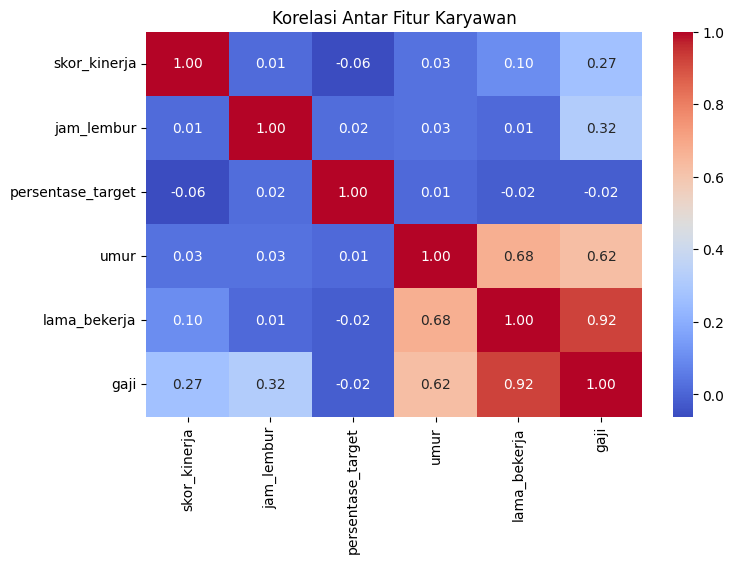

In [4]:
# 2. Eksplorasi Data (EDA)
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur Karyawan')
plt.show()

Heatmap ini digunakan untuk melihat hubungan (korelasi) antar variabel. Angka yang mendekati 1 menunjukkan hubungan yang sangat kuat.

In [5]:
# 3. Membangun Model Regresi Linier
# Menentukan fitur (X) dan target (y)
X = df[['skor_kinerja', 'jam_lembur', 'persentase_target', 'umur', 'lama_bekerja']]
y = df['gaji']

# Split data 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print('Koefisien / Bobot Masing-masing Atribut:')
display(pd.DataFrame(model.coef_, X.columns, columns=['Koefisien']))

Koefisien / Bobot Masing-masing Atribut:


,Koefisien
skor_kinerja,20366.534398
jam_lembur,28507.285696
persentase_target,1024.501896
umur,126.438307
lama_bekerja,148919.744273


Di sini data dibagi menjadi dua: data latih (80%) agar model belajar, dan data uji (20%) untuk mengetes kemampuannya.

In [6]:
# 4. Evaluasi Model
y_pred = model.predict(X_test)
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R-squared (Skor Akurasi):', metrics.r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 160077.96931267256
Root Mean Squared Error (RMSE): 206588.55766393503
R-squared (Skor Akurasi): 0.9796763077413286


Metrik ini menunjukkan seberapa akurat model. R-squared yang mendekati 1 menandakan prediksi model sudah sangat baik.

In [7]:
# 5. Prediksi Data Karyawan Baru
data_baru = pd.DataFrame({
    'skor_kinerja': [85],
    'jam_lembur': [20],
    'persentase_target': [90],
    'umur': [30],
    'lama_bekerja': [5]
})

prediksi = model.predict(data_baru)[0]
print(f'Estimasi Prediksi Gaji: Rp {prediksi:,.0f}')

Estimasi Prediksi Gaji: Rp 6,383,362


Terakhir, kita memasukkan data baru (simulasi karyawan) untuk melihat berapa estimasi gaji yang dihasilkan oleh model.